# Análise Exploratória de Dados (EDA) - Série Histórica de Preços do Arroz

### Validação do Ambiente de Execução
Este bloco realiza uma checagem do interpretador ativo para garantir que o Jupyter Notebook está utilizando o ambiente correto e mapeando adequadamente os caminhos das bibliotecas.

In [3]:
import sys

print("Caminho do Python atual:", sys.executable)
print("\nVersão do Python:", sys.version)
print("\nLista de caminhos de busca (sys.path):")
for path in sys.path:
  print("-", path)

Caminho do Python atual: c:\Users\Bruno Origem Noronha\AppData\Local\Programs\Python\Python313\python.exe

Versão do Python: 3.13.3 (tags/v3.13.3:6280bb5, Apr  8 2025, 14:47:33) [MSC v.1943 64 bit (AMD64)]

Lista de caminhos de busca (sys.path):
- c:\Users\Bruno Origem Noronha\AppData\Local\Programs\Python\Python313\python313.zip
- c:\Users\Bruno Origem Noronha\AppData\Local\Programs\Python\Python313\DLLs
- c:\Users\Bruno Origem Noronha\AppData\Local\Programs\Python\Python313\Lib
- c:\Users\Bruno Origem Noronha\AppData\Local\Programs\Python\Python313
- 
- C:\Users\Bruno Origem Noronha\AppData\Roaming\Python\Python313\site-packages
- c:\Users\Bruno Origem Noronha\AppData\Local\Programs\Python\Python313\Lib\site-packages


### Gerenciamento Robusto de Dependências
Este bloco realiza a instalação programática das bibliotecas essenciais (`pandas`, `numpy`, `matplotlib`) de forma segura, utilizando o módulo `subprocess` em conjunto com o caminho absoluto do interpretador Python ativo (`sys.executable`).

**Justificativa Técnica:** 
Diferente do comando de terminal tradicional (`!pip`), esta abordagem via script evita falhas de interpretação de shell causadas por espaços ou caracteres especiais nos diretórios do sistema operacional (como nomes de usuário no Windows), garantindo que os pacotes sejam injetados com precisão no kernel correto do projeto.

In [6]:
import subprocess
import sys

# Instalação limpa utilizando o executável de forma segura para caminhos com espaços
subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "pandas", "numpy", "matplotlib"]
)
print("Bibliotecas instaladas com sucesso!")

Bibliotecas instaladas com sucesso!


### Inicialização do Ambiente e Identidade Visual Padrão
Este bloco realiza a importação das bibliotecas fundamentais para computação científica e manipulação de dados (`pandas`, `numpy`, `matplotlib`) e define a identidade visual global para todas as figuras da monografia.

**Justificativa Técnica:** 
O uso do dicionário `plt.rcParams.update()` padroniza elementos estéticos essenciais — como a família tipográfica limpa (`sans-serif`), a espessura sutil das bordas dos eixos e a resolução de alta definição (`figure.dpi = 300`) —, garantindo consistência visual e um padrão gráfico estritamente profissional para exportação direta para o documento final.

In [7]:
# Importações fundamentais para manipulação de dados e gráficos
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Configuração de identidade visual padrão para a monografia
LIGHT = "#f8f9fa"
ACCENT = "#2c3e50"  # Cor principal para as séries
ACCENT_SEC = "#e67e22"  # Cor de destaque

plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.edgecolor": "#cccccc",
    "axes.linewidth": 0.8,
    "figure.dpi": 300,  # Garante alta resolução ao exportar as figuras
})

print("Ambiente inicializado com sucesso!")

Ambiente inicializado com sucesso!


### Carregamento e Inspeção Inicial da Base de Dados
Este bloco realiza a importação do dataset tratado de preços do arroz a partir do diretório processado do projeto e executa uma auditoria estrutural inicial dos dados.

**Justificativa Técnica:** 
O uso de `os.path.join()` assegura a portabilidade dos caminhos de diretório entre diferentes sistemas operacionais (como Windows e Linux), evitando erros de referência de arquivos. Em seguida, o método `pd.read_csv()` carrega a série histórica para a memória, enquanto `df_arroz.head()` e `df_arroz.info()` permitem inspecionar visualmente o esquema, validar os tipos primitivos das colunas e checar a integridade estrutural (como contagem de registros e ausência de nulos) antes da modelagem.

In [8]:
import os

# Caminho relativo para o dataset processado de arroz
caminho_dados = os.path.join("..", "data", "processed", "preco_arroz_limpo.csv")

# Se o arquivo estiver na mesma raiz ou se preferir o caminho direto:
# caminho_dados = "../data/processed/preco_arroz_limpo.csv"

# Carregando o DataFrame
df_arroz = pd.read_csv(caminho_dados)

# Exibindo as 5 primeiras linhas para conferir as colunas (ex: Data, Preço)
display(df_arroz.head())

# Exibindo informações gerais (tipos de dados e valores nulos)
df_arroz.info()

,data,preco_brl,preco_usd
0,2008-01-02,23.79,13.43
1,2008-01-03,24.14,13.78
2,2008-01-04,24.23,13.81
3,2008-01-05,24.23,13.81
4,2008-01-06,24.23,13.81


<class 'pandas.DataFrame'>
RangeIndex: 6684 entries, 0 to 6683
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   data       6684 non-null   str    
 1   preco_brl  6684 non-null   float64
 2   preco_usd  6684 non-null   float64
dtypes: float64(2), str(1)
memory usage: 156.8 KB


### Conversão Temporal e Visualização da Série Histórica (BRL)
Este bloco realiza o tratamento cronológico dos dados e gera a primeira visualização gráfica oficial da série histórica de preços do arroz.

**Justificativa Técnica:** 
Primeiramente, a coluna `data` é convertida para o tipo `datetime` do Pandas e o DataFrame é ordenado cronologicamente, assegurando a coerência matemática para o eixo temporal. Em seguida, utiliza-se a biblioteca `matplotlib` configurada com a identidade visual da monografia para plotar a evolução dos preços em Reais (BRL) entre 2008 e 2026. A adição de grade pontilhada, legendas customizadas e o método `plt.tight_layout()` garantem o rigor estético e a legibilidade exigidos em trabalhos acadêmicos.

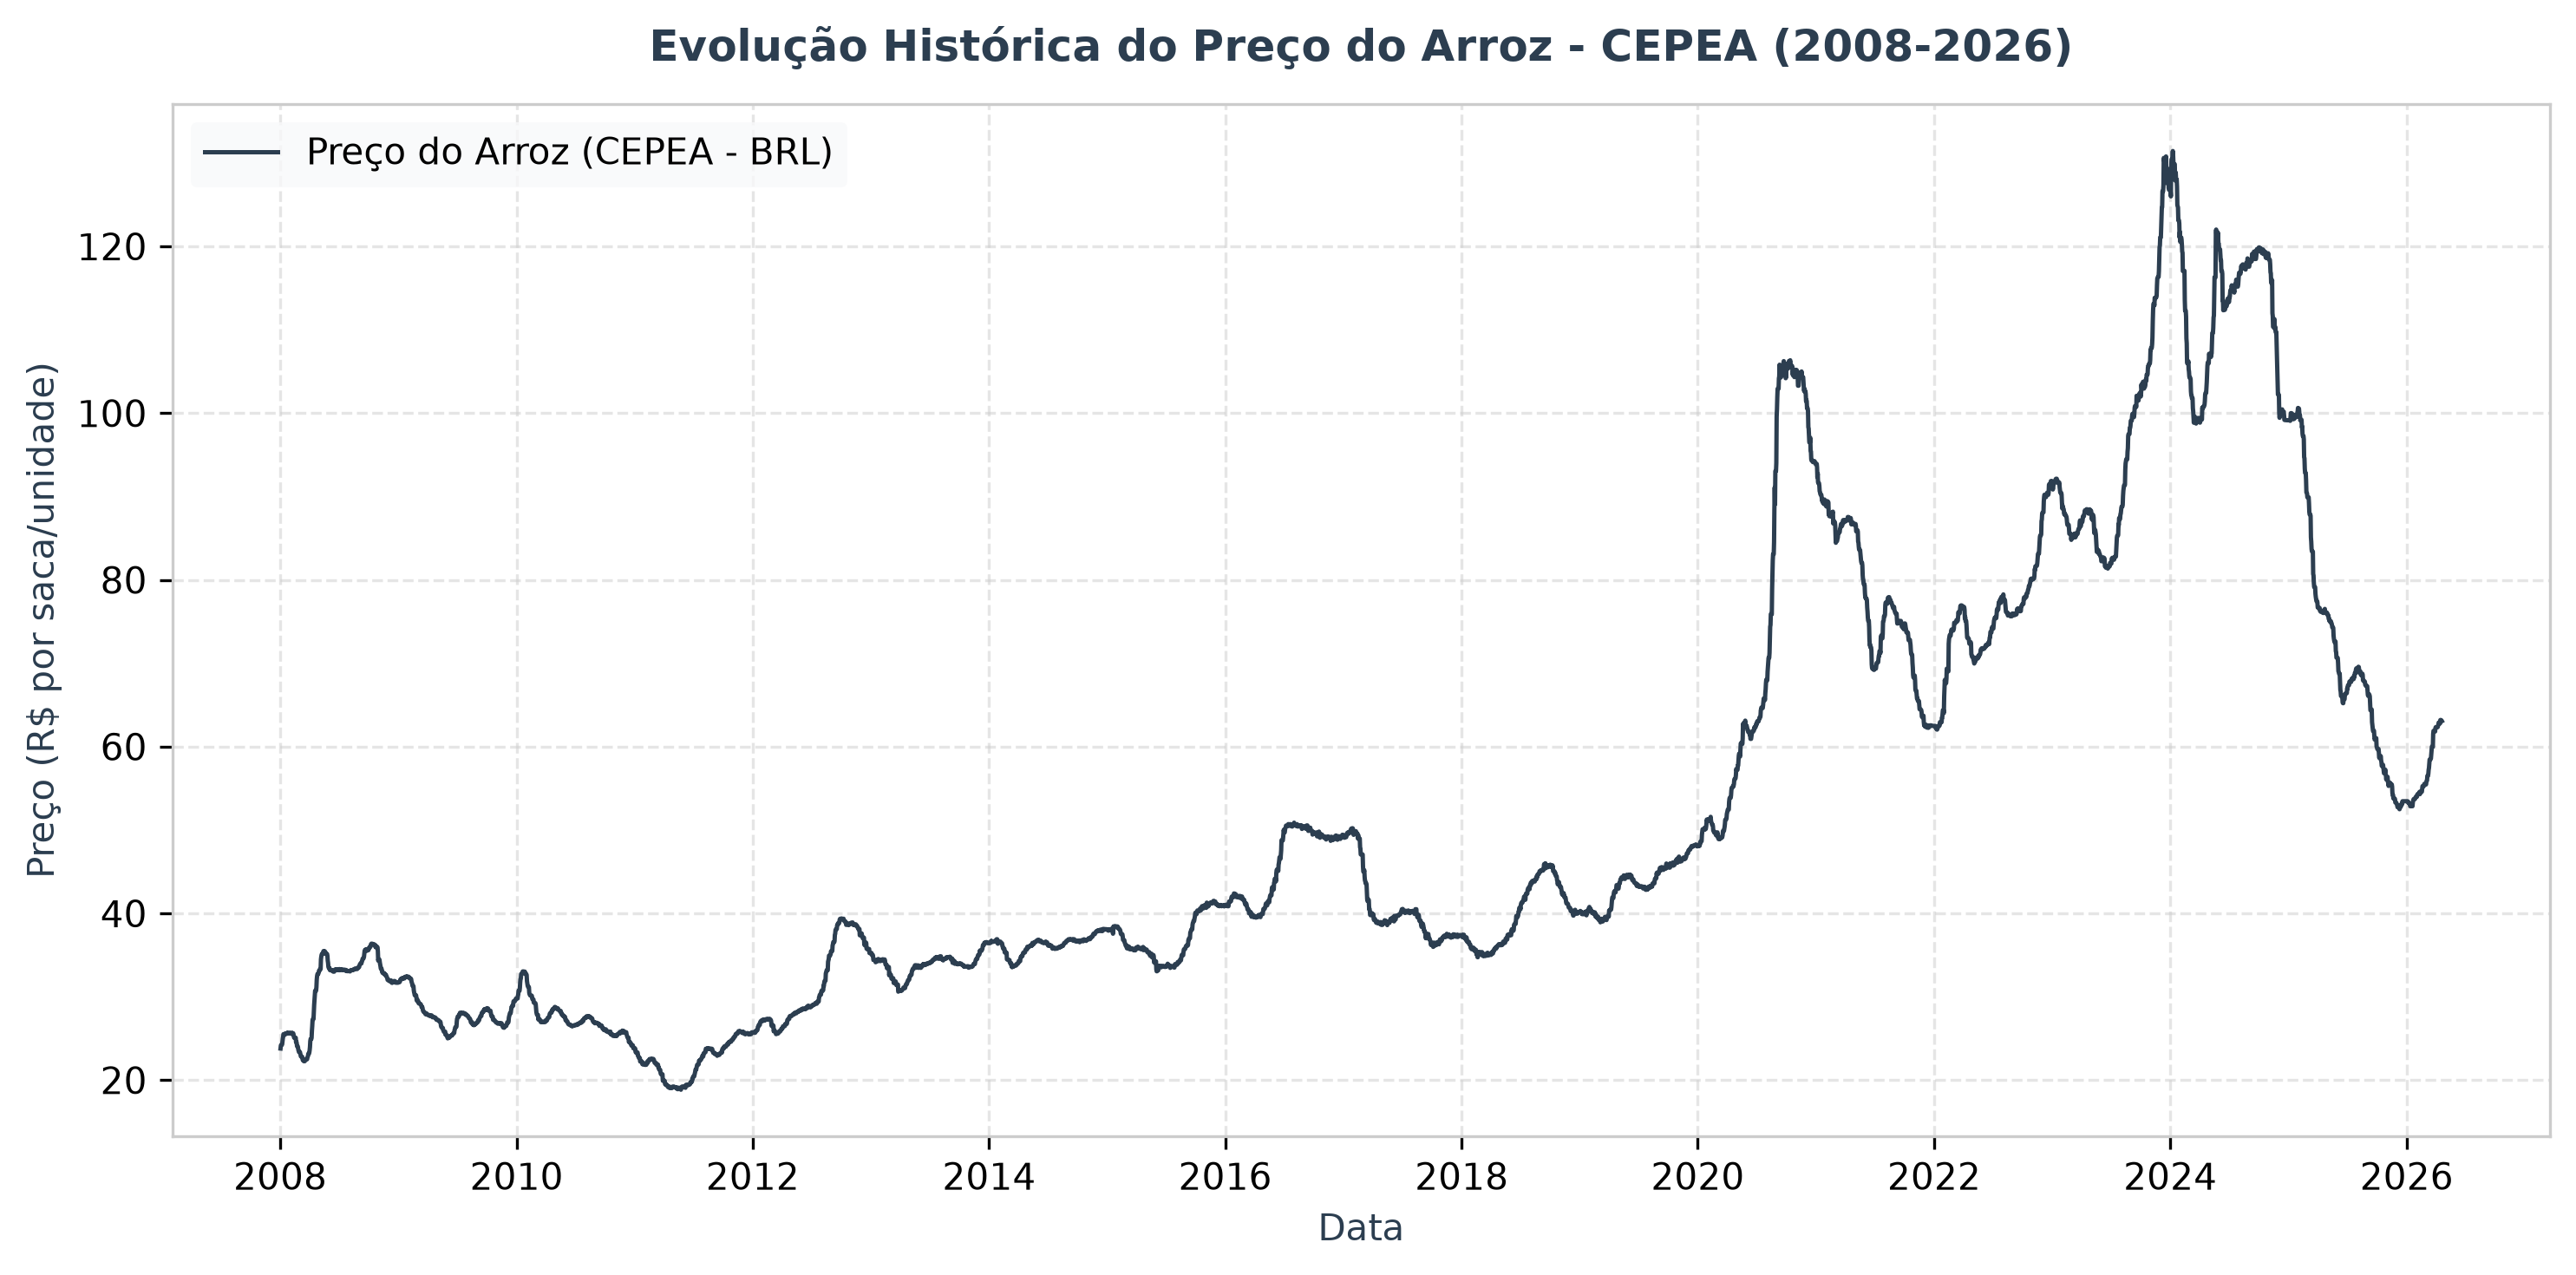

In [9]:
# 1. Convertendo a coluna 'data' para o formato datetime do Pandas
df_arroz['data'] = pd.to_datetime(df_arroz['data'])

# 2. Ordenando cronologicamente por garantia
df_arroz = df_arroz.sort_values('data').reset_index(drop=True)

# 3. Plotagem do Gráfico Histórico de Preços (BRL)
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    df_arroz['data'],
    df_arroz['preco_brl'],
    color=ACCENT,
    linewidth=1.2,
    label='Preço do Arroz (CEPEA - BRL)',
)

# Estilização acadêmica para a monografia
ax.set_title(
    'Evolução Histórica do Preço do Arroz - CEPEA (2008-2026)',
    fontsize=12,
    pad=12,
    color=ACCENT,
    weight='bold',
)
ax.set_xlabel('Data', fontsize=10, color=ACCENT)
ax.set_ylabel('Preço (R$ por saca/unidade)', fontsize=10, color=ACCENT)
ax.grid(True, linestyle='--', alpha=0.5, color='#cccccc')
ax.legend(frameon=True, facecolor=LIGHT, edgecolor='none')

# Ajusta o layout para evitar cortes
plt.tight_layout()

# Exibe o gráfico no notebook
plt.show()

A visualização da série histórica do preço do arroz (CEPEA) em Reais (BRL) entre 2008 e 2026[cite: 4] evidencia dinâmicas macroeconômicas importantes para o escopo do TCC:

* **Período de Estabilidade (2008–2019):** Os anos iniciais apresentam patamares de preços predominantemente estáveis, oscilando majoritariamente entre R$ 20,00 e R$ 40,00 por saca[cite: 4], refletindo um cenário de menor volatilidade inflacionária e cambial no setor arrozeiro.
* **Choques e Alta Volatilidade Pós-2020:** Observa-se uma inflexão acentuada a partir de 2020[cite: 4], impulsionada por fatores como a pandemia de COVID-19, desvalorização cambial, aumento nos custos dos insumos agrícolas e choques na demanda internacional. Os preços atingem picos históricos expressivos superando a marca de R$ 120,00[cite: 4].
* **Ciclicidade Recente:** Entre 2021 e 2026[cite: 4], a série demonstra oscilações cíclicas agudas, com novas pressões de alta nos anos de 2023 e 2024[cite: 4], seguidas por correções parciais no mercado físico.

**Implicação para a Modelagem:** A alta não-estacionaridade e a presença de quebras estruturais marcadas nos últimos anos reforçam a necessidade de engenharia de features robusta e o uso de modelos de séries temporais capazes de capturar tendências de longo prazo e volatilidade (como redes neurais LSTM).